[1/3] 자산별 데이터 파일 로드 및 병합 시작...
  - youtube_videos_full1.csv 로드 완료: 83,226건
  - youtube_videos_full2.csv 로드 완료: 41,766건
  - youtube_videos_full3.csv 로드 완료: 68,563건
-> 전체 파일 초기 병합 완료: 총 193,555건
-> 중복 제거 후 최종 유니크 데이터: 총 151,789건
-> 2018_Q1 ~ 2026_Q2 필터링 후 데이터: 총 150,196건
[2/3] 분기별 자산 키워드 집계 중...
[3/3] 통합 데이터 시각화 차트 생성 중...
[완료] 통합 시각화 차트가 'shaman_triple_combined_trend.png' 파일로 저장되었습니다.


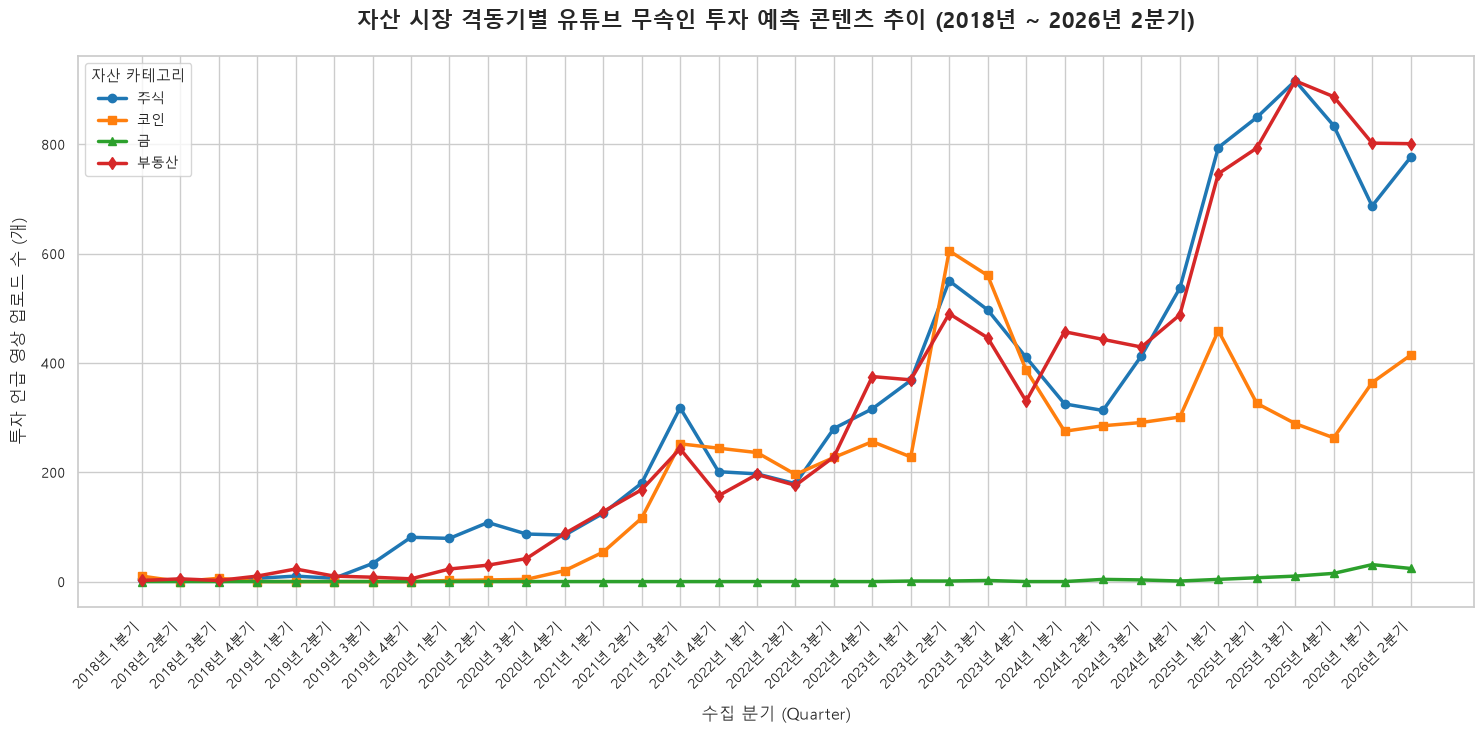

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# =========================================================
# 2. 다중 데이터 파일 자동 병합 및 전처리
# =========================================================
# 합칠 파일 목록 리스트 (나중에 파일이 더 늘어나면 여기에 파일명만 추가하면 됩니다)
file_list = [
    'youtube_videos_full1.csv', 
    'youtube_videos_full2.csv', 
    'youtube_videos_full3.csv'
]

data_frames = []

print("[1/3] 자산별 데이터 파일 로드 및 병합 시작...")
for file_name in file_list:
    if os.path.exists(file_name):
        try:
            temp_df = pd.read_csv(file_name, encoding='utf-8-sig')
            data_frames.append(temp_df)
            print(f"  - {file_name} 로드 완료: {len(temp_df):,}건")
        except Exception as e:
            print(f"  - [경고] {file_name} 읽기 실패: {e}")
    else:
        print(f"  - [경고] {file_name} 파일이 현재 경로에 존재하지 않습니다. 건너뜁니다.")

if not data_frames:
    print("[오류] 읽어올 수 있는 CSV 파일이 단 하나도 없습니다. 파일명을 확인해주세요.")
    exit()

# 데이터프레임 전체 병합
df = pd.concat(data_frames, ignore_index=True)
print(f"-> 전체 파일 초기 병합 완료: 총 {len(df):,}건")

# 영상 ID(video_id) 기준 중복 제거 (여러 파일에 걸쳐 중복 수집된 데이터 정제)
df = df.drop_duplicates(subset=['video_id']).reset_index(drop=True)
print(f"-> 중복 제거 후 최종 유니크 데이터: 총 {len(df):,}건")

# 분기 데이터 정제 (UNKNOWN 및 결측치 제거)
df = df[df['collected_q'].notna() & (df['collected_q'] != 'UNKNOWN')]

# =========================================================
# 3. 자산별 분기 데이터 집계 (텍스트 파싱 및 카운트)
# =========================================================
print("[2/3] 분기별 자산 키워드 집계 중...")
target_assets = ['주식', '코인', '금', '부동산']
quarter_list = sorted(df['collected_q'].unique())

quarterly_counts = []
for q in quarter_list:
    q_df = df[df['collected_q'] == q]
    row = {'분기': q}
    
    for asset in target_assets:
        # asset_class 컬럼에 해당 자산 명칭이 포함되어 있는지 판별하여 카운트
        row[asset] = q_df['asset_class'].fillna('').str.contains(asset).sum()
        
    quarterly_counts.append(row)

# 시각화용 최종 데이터프레임 빌드
trend_df = pd.DataFrame(quarterly_counts).set_index('분기')

# =========================================================
# 4. 데이터 저널리즘 스타일 차트 생성 (Line Plot)
# =========================================================
print("[3/3] 통합 데이터 시각화 차트 생성 중...")
plt.figure(figsize=(15, 7.5))

# 자산별 고유 색상 및 마커 매핑
colors = {'주식': '#1f77b4', '코인': '#ff7f0e', '금': '#2ca02c', '부동산': '#d62728'}
markers = {'주식': 'o', '코인': 's', '금': '^', '부동산': 'd'}

for asset in target_assets:
    plt.plot(trend_df.index, trend_df[asset], 
             marker=markers[asset], 
             color=colors[asset], 
             linewidth=2.5, 
             label=asset,
             markersize=6)

# 차트 세부 레이아웃 및 텍스트 튜닝
plt.title('자산 시장 격동기별 유튜브 무속인 투자 예측 콘텐츠 추이 (전체 패널 전수조사)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('수집 분기 (Quarter)', fontsize=12, labelpad=10)
plt.ylabel('투자 언급 영상 업로드 수 (개)', fontsize=12, labelpad=10)

# X축 레이블이 겹치지 않도록 사선 회전 및 폰트 크기 조정
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='자산 카테고리', title_fontsize='11', fontsize='10', loc='upper left')

# 이미지 최적화 저장 및 출력
plt.tight_layout()
output_image_name = 'shaman_triple_combined_trend.png'
plt.savefig(output_image_name, dpi=300)
print(f"[완료] 통합 시각화 차트가 '{output_image_name}' 파일로 저장되었습니다.")
plt.show()

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# =========================================================
# 2. 다중 데이터 파일 자동 병합 및 전처리
# =========================================================
file_list = [
    'youtube_videos_full1.csv', 
    'youtube_videos_full2.csv', 
    'youtube_videos_full3.csv'
]

data_frames = []

print("[1/3] 자산별 데이터 파일 로드 및 병합 시작...")
for file_name in file_list:
    if os.path.exists(file_name):
        try:
            temp_df = pd.read_csv(file_name, encoding='utf-8-sig')
            data_frames.append(temp_df)
            print(f"  - {file_name} 로드 완료: {len(temp_df):,}건")
        except Exception as e:
            print(f"  - [경고] {file_name} 읽기 실패: {e}")
    else:
        print(f"  - [경고] {file_name} 파일이 현재 경로에 존재하지 않습니다. 건너뜁니다.")

if not data_frames:
    print("[오류] 읽어올 수 있는 CSV 파일이 단 하나도 없습니다. 파일명을 확인해주세요.")
    exit()

# 데이터프레임 전체 병합
df = pd.concat(data_frames, ignore_index=True)
print(f"-> 전체 파일 초기 병합 완료: 총 {len(df):,}건")

# 영상 ID(video_id) 기준 중복 제거
df = df.drop_duplicates(subset=['video_id']).reset_index(drop=True)
print(f"-> 중복 제거 후 최종 유니크 데이터: 총 {len(df):,}건")

# 분기 데이터 정제 (UNKNOWN 및 결측치 제거)
df = df[df['collected_q'].notna() & (df['collected_q'] != 'UNKNOWN')]

# [수정] 2018년 1분기(2018_Q1)부터 2026년 2분기(2026_Q2)까지 기간 필터링 추가
df = df[(df['collected_q'] >= '2018_Q1') & (df['collected_q'] <= '2026_Q2')]
print(f"-> 2018_Q1 ~ 2026_Q2 필터링 후 데이터: 총 {len(df):,}건")


# =========================================================
# 3. 자산별 분기 데이터 집계 (텍스트 파싱 및 카운트)
# =========================================================
print("[2/3] 분기별 자산 키워드 집계 중...")
target_assets = ['주식', '코인', '금', '부동산']
quarter_list = sorted(df['collected_q'].unique())

quarterly_counts = []
for q in quarter_list:
    q_df = df[df['collected_q'] == q]
    row = {'분기': q}
    
    for asset in target_assets:
        row[asset] = q_df['asset_class'].fillna('').str.contains(asset).sum()
        
    quarterly_counts.append(row)

# 시각화용 최종 데이터프레임 빌드
trend_df = pd.DataFrame(quarterly_counts).set_index('분기')

# [수정] 차트 표시를 위해 분기 문자열 포맷 변경 (예: 2024_Q1 -> 2024년 1분기)
trend_df.index = trend_df.index.str.replace('_Q1', '년 1분기') \
                              .str.replace('_Q2', '년 2분기') \
                              .str.replace('_Q3', '년 3분기') \
                              .str.replace('_Q4', '년 4분기')


# =========================================================
# 4. 데이터 저널리즘 스타일 차트 생성 (Line Plot)
# =========================================================
print("[3/3] 통합 데이터 시각화 차트 생성 중...")
plt.figure(figsize=(15, 7.5))

# 자산별 고유 색상 및 마커 매핑
colors = {'주식': '#1f77b4', '코인': '#ff7f0e', '금': '#2ca02c', '부동산': '#d62728'}
markers = {'주식': 'o', '코인': 's', '금': '^', '부동산': 'd'}

for asset in target_assets:
    plt.plot(trend_df.index, trend_df[asset], 
             marker=markers[asset], 
             color=colors[asset], 
             linewidth=2.5, 
             label=asset,
             markersize=6)

# 차트 세부 레이아웃 및 텍스트 튜닝
plt.title('자산 시장 격동기별 유튜브 무속인 투자 예측 콘텐츠 추이 (2018년 ~ 2026년 2분기)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('수집 분기 (Quarter)', fontsize=12, labelpad=10)
plt.ylabel('투자 언급 영상 업로드 수 (개)', fontsize=12, labelpad=10)

# X축 레이블 사선 회전 및 폰트 설정
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='자산 카테고리', title_fontsize='11', fontsize='10', loc='upper left')

# 이미지 최적화 저장 및 출력
plt.tight_layout()
output_image_name = 'shaman_triple_combined_trend.png'
plt.savefig(output_image_name, dpi=300)
print(f"[완료] 통합 시각화 차트가 '{output_image_name}' 파일로 저장되었습니다.")
plt.show()

[1/3] 자산별 데이터 파일 로드 및 병합 시작...
  - youtube_videos_full1.csv 로드 완료: 83,226건
  - youtube_videos_full2.csv 로드 완료: 41,766건
  - youtube_videos_full3.csv 로드 완료: 68,563건
-> 전체 파일 초기 병합 완료: 총 193,555건
-> 중복 제거 후 최종 유니크 데이터: 총 151,789건
-> 2018_Q1 ~ 2026_Q2 필터링 후 데이터: 총 150,196건
[2/3] 분기별 자산 키워드 집계 중...
[3/3] 자산별 개별 시각화 차트 생성 및 저장 중...
  - '주식' 차트가 'shaman_trend_주식.png' 파일로 저장되었습니다.


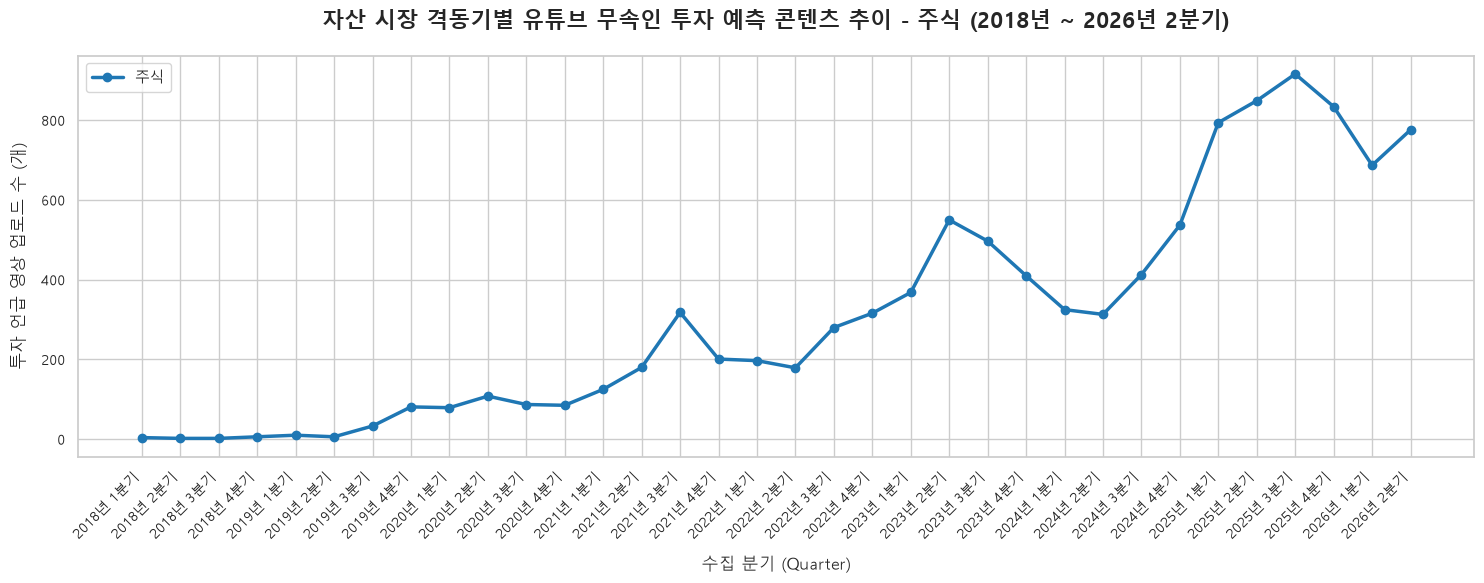

  - '코인' 차트가 'shaman_trend_코인.png' 파일로 저장되었습니다.


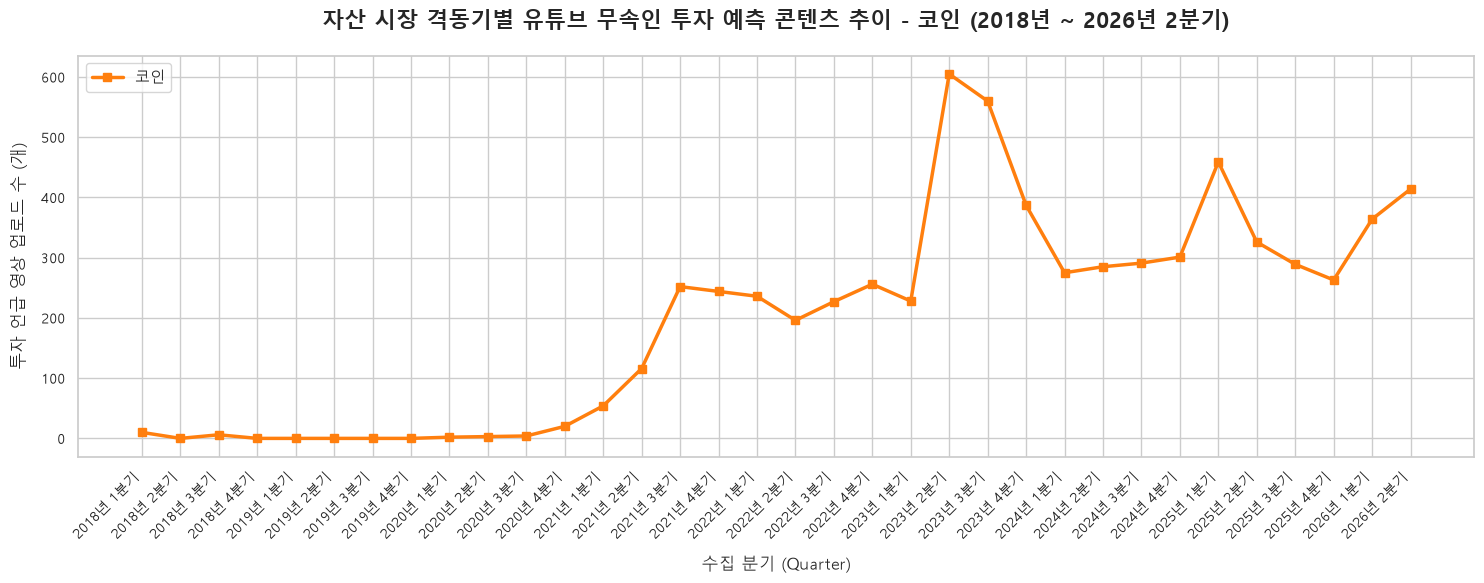

  - '금' 차트가 'shaman_trend_금.png' 파일로 저장되었습니다.


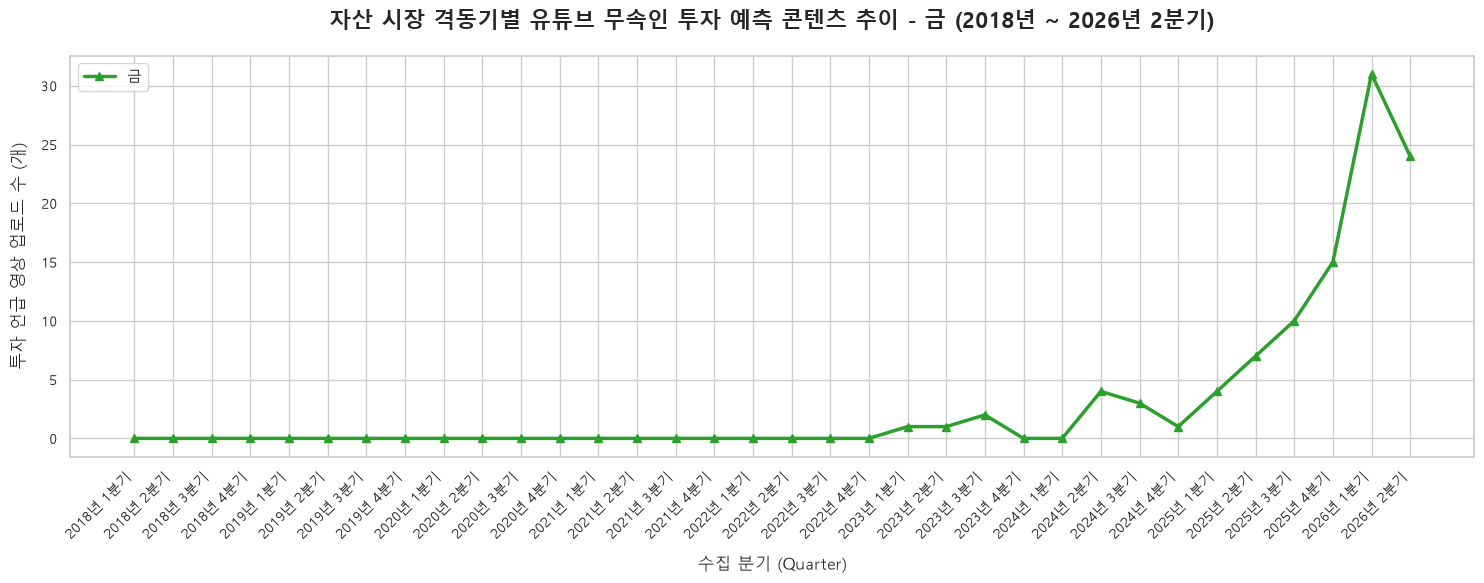

  - '부동산' 차트가 'shaman_trend_부동산.png' 파일로 저장되었습니다.


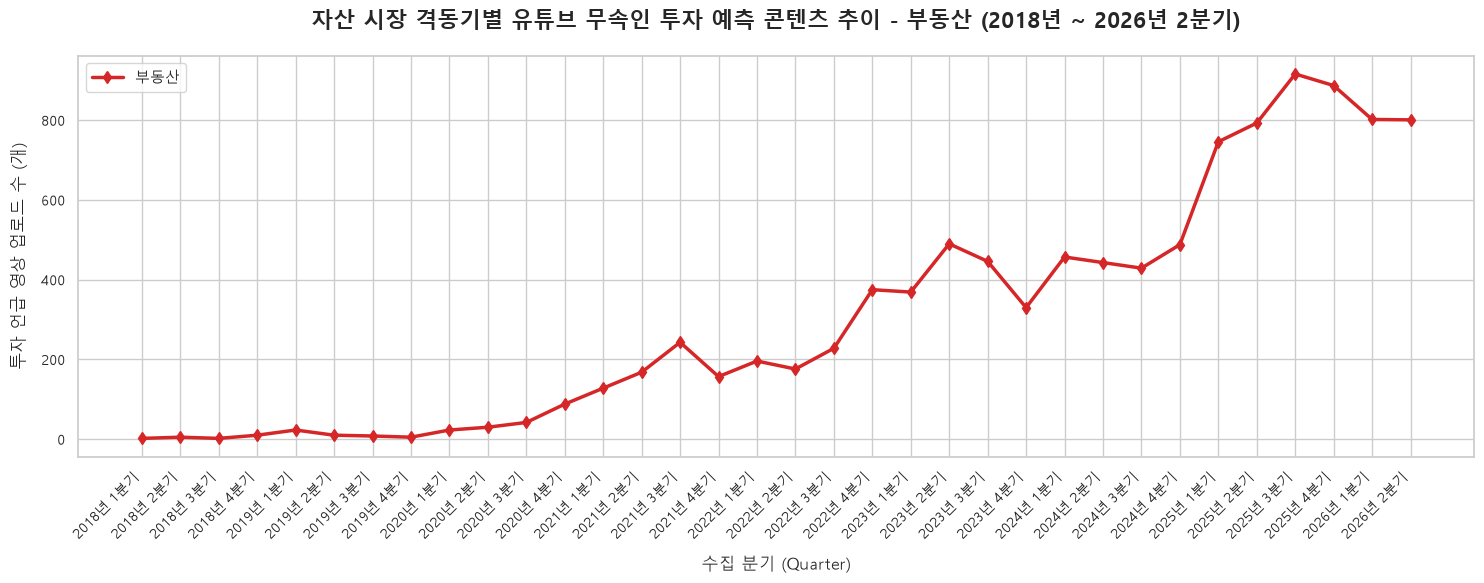

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# =========================================================
# 2. 다중 데이터 파일 자동 병합 및 전처리
# =========================================================
file_list = [
    'youtube_videos_full1.csv', 
    'youtube_videos_full2.csv', 
    'youtube_videos_full3.csv'
]

data_frames = []

print("[1/3] 자산별 데이터 파일 로드 및 병합 시작...")
for file_name in file_list:
    if os.path.exists(file_name):
        try:
            temp_df = pd.read_csv(file_name, encoding='utf-8-sig')
            data_frames.append(temp_df)
            print(f"  - {file_name} 로드 완료: {len(temp_df):,}건")
        except Exception as e:
            print(f"  - [경고] {file_name} 읽기 실패: {e}")
    else:
        print(f"  - [경고] {file_name} 파일이 현재 경로에 존재하지 않습니다. 건너뜁니다.")

if not data_frames:
    print("[오류] 읽어올 수 있는 CSV 파일이 단 하나도 없습니다. 파일명을 확인해주세요.")
    exit()

# 데이터프레임 전체 병합
df = pd.concat(data_frames, ignore_index=True)
print(f"-> 전체 파일 초기 병합 완료: 총 {len(df):,}건")

# 영상 ID(video_id) 기준 중복 제거
df = df.drop_duplicates(subset=['video_id']).reset_index(drop=True)
print(f"-> 중복 제거 후 최종 유니크 데이터: 총 {len(df):,}건")

# 분기 데이터 정제 (UNKNOWN 및 결측치 제거)
df = df[df['collected_q'].notna() & (df['collected_q'] != 'UNKNOWN')]

# 2018년 1분기(2018_Q1)부터 2026년 2분기(2026_Q2)까지 기간 필터링
df = df[(df['collected_q'] >= '2018_Q1') & (df['collected_q'] <= '2026_Q2')]
print(f"-> 2018_Q1 ~ 2026_Q2 필터링 후 데이터: 총 {len(df):,}건")


# =========================================================
# 3. 자산별 분기 데이터 집계 (텍스트 파싱 및 카운트)
# =========================================================
print("[2/3] 분기별 자산 키워드 집계 중...")
target_assets = ['주식', '코인', '금', '부동산']
quarter_list = sorted(df['collected_q'].unique())

quarterly_counts = []
for q in quarter_list:
    q_df = df[df['collected_q'] == q]
    row = {'분기': q}
    
    for asset in target_assets:
        row[asset] = q_df['asset_class'].fillna('').str.contains(asset).sum()
        
    quarterly_counts.append(row)

# 시각화용 최종 데이터프레임 빌드
trend_df = pd.DataFrame(quarterly_counts).set_index('분기')

# 차트 표시를 위해 분기 문자열 포맷 변경 (예: 2024_Q1 -> 2024년 1분기)
trend_df.index = trend_df.index.str.replace('_Q1', '년 1분기') \
                              .str.replace('_Q2', '년 2분기') \
                              .str.replace('_Q3', '년 3분기') \
                              .str.replace('_Q4', '년 4분기')


# =========================================================
# 4. 자산별 독립 차트 생성 및 저장 (Line Plot)
# =========================================================
print("[3/3] 자산별 개별 시각화 차트 생성 및 저장 중...")

# 자산별 고유 색상 및 마커 매핑
colors = {'주식': '#1f77b4', '코인': '#ff7f0e', '금': '#2ca02c', '부동산': '#d62728'}
markers = {'주식': 'o', '코인': 's', '금': '^', '부동산': 'd'}

# 자산별로 반복문을 돌며 독립된 차트를 생성합니다.
for asset in target_assets:
    plt.figure(figsize=(15, 6))
    
    plt.plot(trend_df.index, trend_df[asset], 
             marker=markers[asset], 
             color=colors[asset], 
             linewidth=2.5, 
             label=asset,
             markersize=6)

    # 차트 세부 레이아웃 및 텍스트 튜닝
    plt.title(f'자산 시장 격동기별 유튜브 무속인 투자 예측 콘텐츠 추이 - {asset} (2018년 ~ 2026년 2분기)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('수집 분기 (Quarter)', fontsize=12, labelpad=10)
    plt.ylabel('투자 언급 영상 업로드 수 (개)', fontsize=12, labelpad=10)

    # X축 레이블 사선 회전 및 폰트 설정
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(loc='upper left', fontsize='11')

    # 이미지 최적화 저장 및 출력
    plt.tight_layout()
    output_image_name = f'shaman_trend_{asset}.png'
    plt.savefig(output_image_name, dpi=300)
    print(f"  - '{asset}' 차트가 '{output_image_name}' 파일로 저장되었습니다.")
    plt.show()
    plt.close() # 메모리 해제를 위해 현재 생성된 figure 닫기

[1/4] 데이터 파일 로드 및 병합...
  - youtube_videos_full1.csv 로드 완료: 83,226건
  - youtube_videos_full2.csv 로드 완료: 41,766건
  - youtube_videos_full3.csv 로드 완료: 68,563건
-> 정제 후 최종 150,196건
-> is_investment 컬럼 감지: '전체 대비 투자영상 비중'으로 계산
[2/4] 분기별 집계...
[3/4] 그래프 생성...


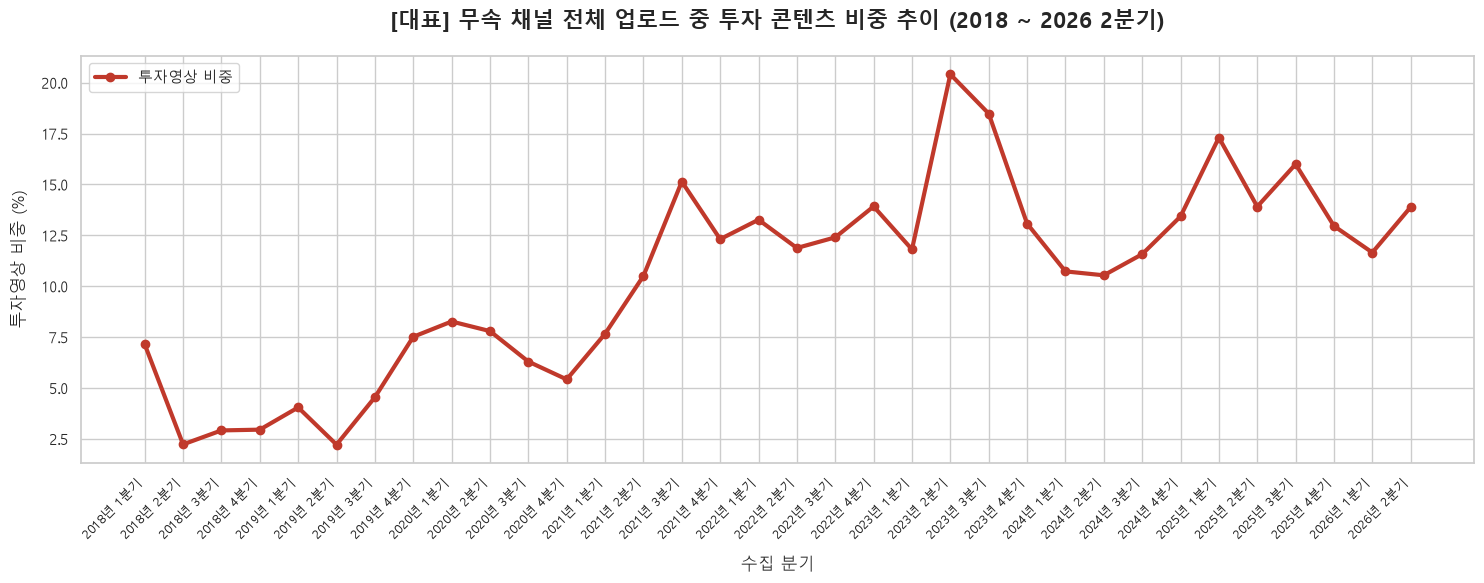

  - 대표(비중) 차트 저장: trend_00_투자비중_대표.png


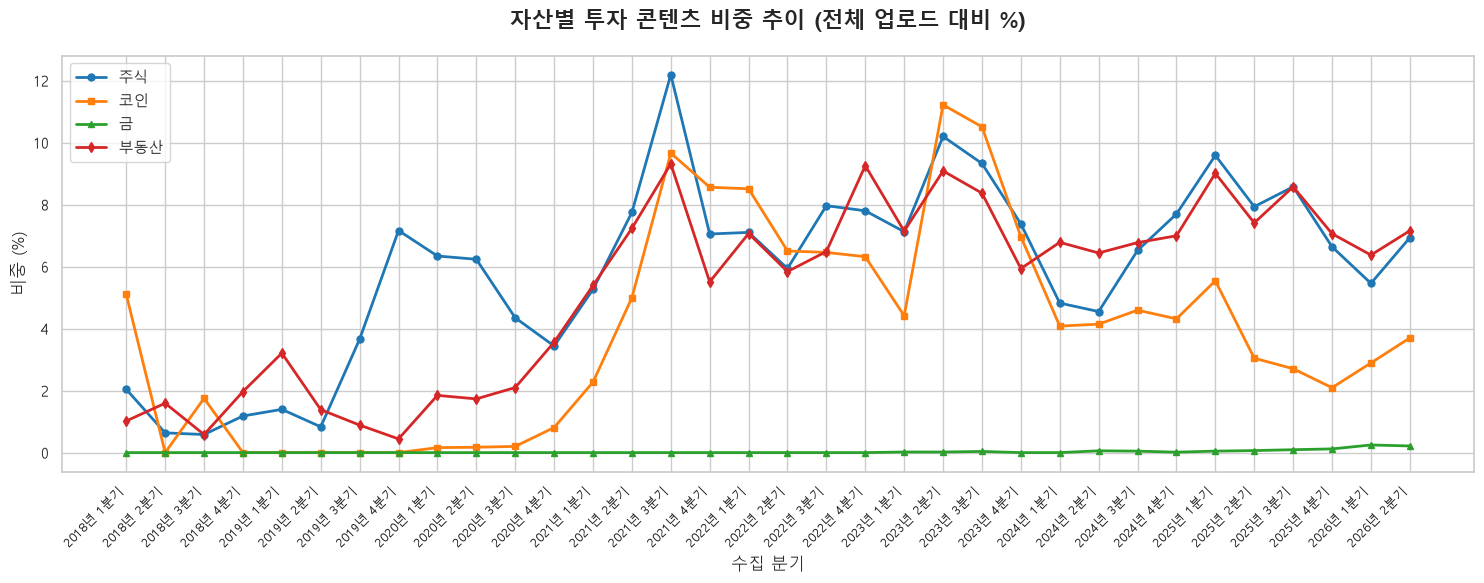

  - 자산별 비중 차트 저장: trend_01_자산별비중.png


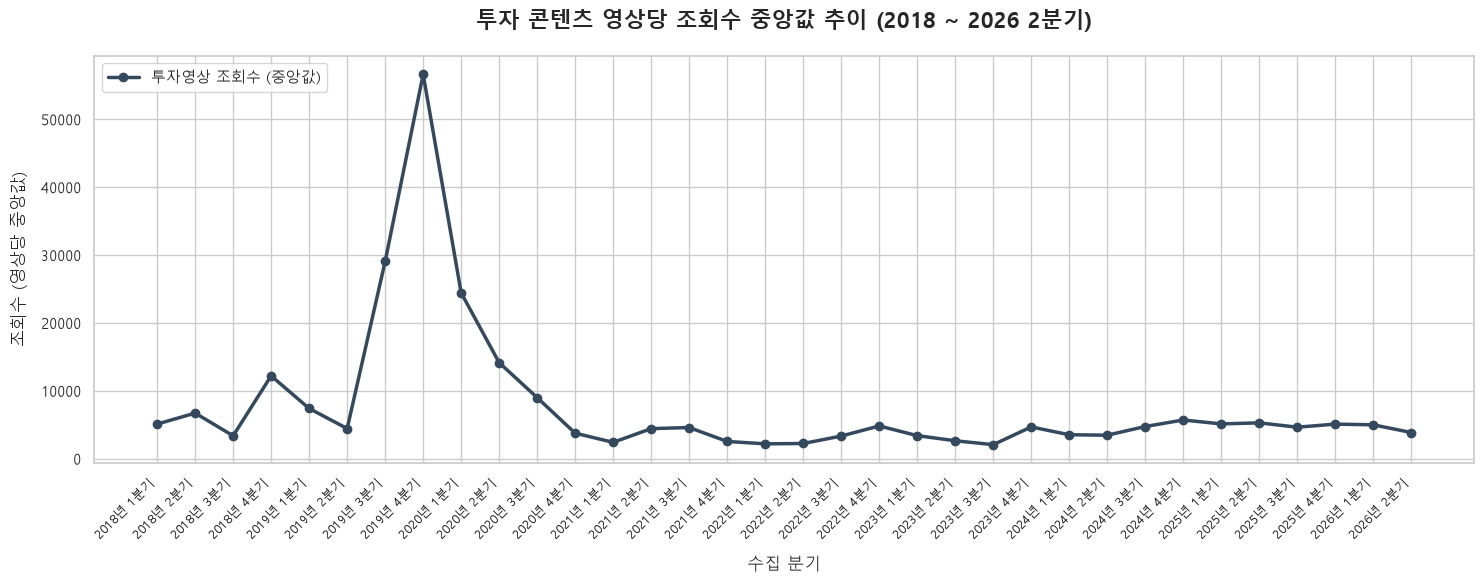

  - 조회수 차트 저장: trend_metric_view_count.png


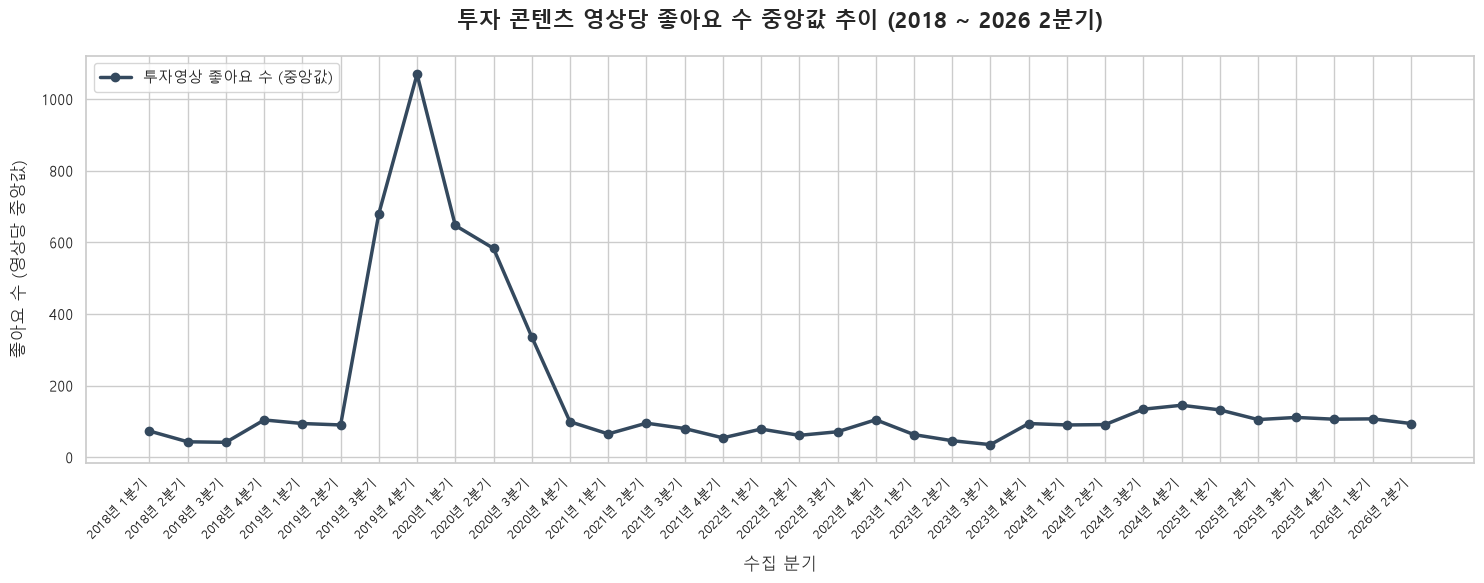

  - 좋아요 수 차트 저장: trend_metric_like_count.png


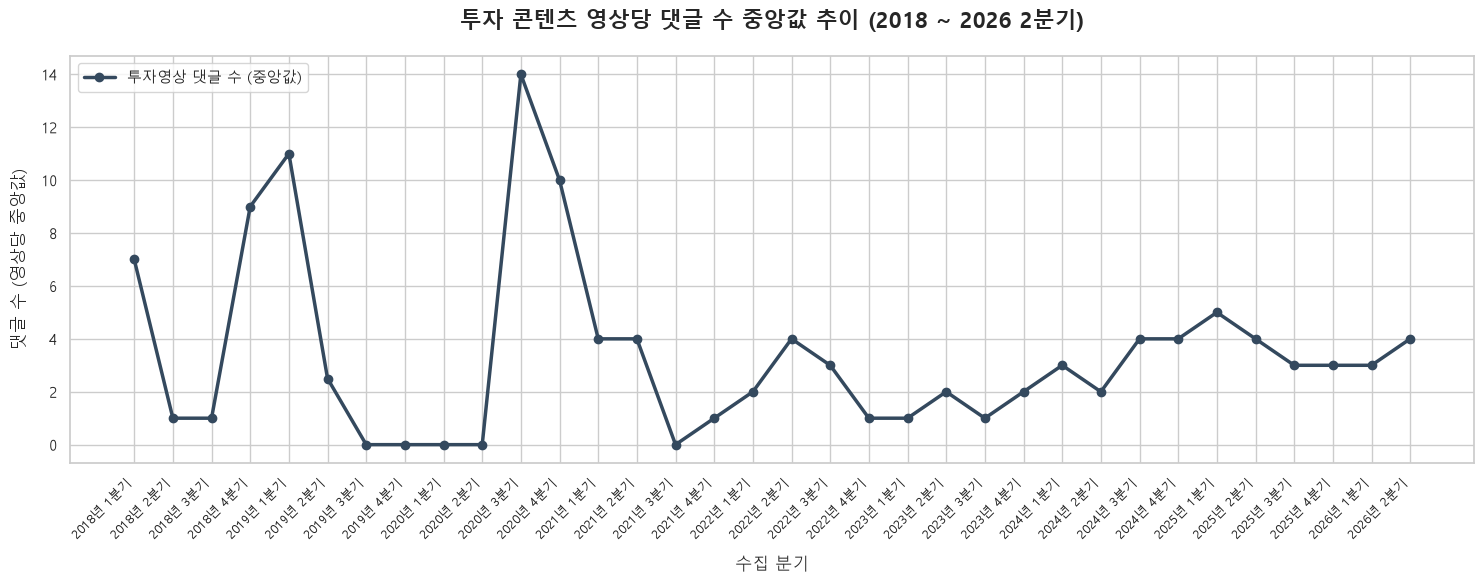

  - 댓글 수 차트 저장: trend_metric_comment_count.png
[4/4] 완료. 발표에는 trend_00(비중)을 대표로 사용하고, 나머지는 질문 대비용으로 보관하세요.

※ 참고: 조회수·좋아요·댓글은 '수집 시점 누적값'이라 추세축으로는 왜곡이 있습니다.
   (옛 영상일수록 조회수가 쌓일 시간이 길었음) → 합계 대신 '영상당 중앙값'으로 그렸습니다.


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. 한글 폰트 설정
# =========================================================
plt.rc('font', family='Malgun Gothic')       # Mac이면 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# =========================================================
# 2. 다중 데이터 파일 병합 및 전처리
# =========================================================
file_list = [
    'youtube_videos_full1.csv',
    'youtube_videos_full2.csv',
    'youtube_videos_full3.csv',
]

data_frames = []
print("[1/4] 데이터 파일 로드 및 병합...")
for file_name in file_list:
    if os.path.exists(file_name):
        try:
            temp_df = pd.read_csv(file_name, encoding='utf-8-sig')
            data_frames.append(temp_df)
            print(f"  - {file_name} 로드 완료: {len(temp_df):,}건")
        except Exception as e:
            print(f"  - [경고] {file_name} 읽기 실패: {e}")
    else:
        print(f"  - [경고] {file_name} 없음. 건너뜁니다.")

if not data_frames:
    raise SystemExit("[오류] 읽어올 CSV가 없습니다. 파일명을 확인하세요.")

df = pd.concat(data_frames, ignore_index=True)
df = df.drop_duplicates(subset=['video_id']).reset_index(drop=True)
df = df[df['collected_q'].notna() & (df['collected_q'] != 'UNKNOWN')]
df = df[(df['collected_q'] >= '2018_Q1') & (df['collected_q'] <= '2026_Q2')]
print(f"-> 정제 후 최종 {len(df):,}건")

# 통계 컬럼을 숫자로 강제 변환 (문자/결측 -> 0)
for col in ['view_count', 'like_count', 'comment_count']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# is_investment 컬럼 유무 확인 (비중 계산 방식 결정)
HAS_INV = 'is_investment' in df.columns
if HAS_INV:
    df['is_investment'] = df['is_investment'].astype(str).str.lower().isin(['true', '1', 'yes'])
    print("-> is_investment 컬럼 감지: '전체 대비 투자영상 비중'으로 계산")
else:
    print("-> is_investment 없음: asset_class가 채워진 영상을 투자영상으로 간주")
    df['is_investment'] = df['asset_class'].fillna('').str.strip().ne('')

# =========================================================
# 3. 분기별 집계
# =========================================================
print("[2/4] 분기별 집계...")
target_assets = ['주식', '코인', '금', '부동산']
colors = {'주식': '#1f77b4', '코인': '#ff7f0e', '금': '#2ca02c', '부동산': '#d62728'}
markers = {'주식': 'o', '코인': 's', '금': '^', '부동산': 'd'}

def fmt_q(idx):
    """2024_Q1 -> 2024년 1분기"""
    return (idx.str.replace('_Q1', '년 1분기').str.replace('_Q2', '년 2분기')
               .str.replace('_Q3', '년 3분기').str.replace('_Q4', '년 4분기'))

quarter_list = sorted(df['collected_q'].unique())
inv_df = df[df['is_investment']]        # 투자 영상만

# (A) 비중: 분기별 (투자영상 수 / 전체 업로드 수) × 100
share_rows = []
for q in quarter_list:
    q_all = df[df['collected_q'] == q]
    q_inv = q_all[q_all['is_investment']]
    total = len(q_all)
    row = {'분기': q, '투자영상_비중': (len(q_inv) / total * 100) if total else 0.0}
    # 자산별 비중도 함께 계산
    for asset in target_assets:
        n_asset = q_all['asset_class'].fillna('').str.contains(asset).sum()
        row[asset] = (n_asset / total * 100) if total else 0.0
    share_rows.append(row)
share_df = pd.DataFrame(share_rows).set_index('분기')
share_df.index = fmt_q(share_df.index)

# (B) 조회수 / (C) 좋아요 / (D) 댓글: 투자영상 '영상당 중앙값' (합계는 영상수에 휘둘리므로)
metric_map = {'view_count': '조회수', 'like_count': '좋아요 수', 'comment_count': '댓글 수'}
metric_df = (
    inv_df.groupby('collected_q')[list(metric_map.keys())]
          .median()
          .reindex(quarter_list)
)
metric_df.index = fmt_q(pd.Series(metric_df.index))

# =========================================================
# 4. 그래프 생성
# =========================================================
print("[3/4] 그래프 생성...")

def style_xaxis(ax):
    ax.set_xticks(range(len(ax.get_xticklabels()) or 0))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

# ---- (대표) 투자영상 비중 추세 ----
plt.figure(figsize=(15, 6))
ax = plt.gca()
ax.plot(share_df.index, share_df['투자영상_비중'],
        marker='o', color='#c0392b', linewidth=3, markersize=6, label='투자영상 비중')
ax.set_title('[대표] 무속 채널 전체 업로드 중 투자 콘텐츠 비중 추이 (2018 ~ 2026 2분기)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('수집 분기', fontsize=12, labelpad=10)
ax.set_ylabel('투자영상 비중 (%)', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.savefig('trend_00_투자비중_대표.png', dpi=300)
plt.show(); plt.close()
print("  - 대표(비중) 차트 저장: trend_00_투자비중_대표.png")

# ---- 자산별 비중 (한 장에 4개 선) ----
plt.figure(figsize=(15, 6))
for asset in target_assets:
    plt.plot(share_df.index, share_df[asset],
             marker=markers[asset], color=colors[asset], linewidth=2, markersize=5, label=asset)
plt.title('자산별 투자 콘텐츠 비중 추이 (전체 업로드 대비 %)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('수집 분기', fontsize=12); plt.ylabel('비중 (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.savefig('trend_01_자산별비중.png', dpi=300)
plt.show(); plt.close()
print("  - 자산별 비중 차트 저장: trend_01_자산별비중.png")

# ---- 조회수 / 좋아요 / 댓글 (영상당 중앙값) ----
for col, kor in metric_map.items():
    plt.figure(figsize=(15, 6))
    plt.plot(metric_df.index, metric_df[col],
             marker='o', color='#34495e', linewidth=2.5, markersize=6, label=f'투자영상 {kor} (중앙값)')
    plt.title(f'투자 콘텐츠 영상당 {kor} 중앙값 추이 (2018 ~ 2026 2분기)',
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('수집 분기', fontsize=12, labelpad=10)
    plt.ylabel(f'{kor} (영상당 중앙값)', fontsize=12, labelpad=10)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.legend(loc='upper left', fontsize=11)
    plt.tight_layout()
    fname = f'trend_metric_{col}.png'
    plt.savefig(fname, dpi=300)
    plt.show(); plt.close()
    print(f"  - {kor} 차트 저장: {fname}")

print("[4/4] 완료. 발표에는 trend_00(비중)을 대표로 사용하고, 나머지는 질문 대비용으로 보관하세요.")
print("\n※ 참고: 조회수·좋아요·댓글은 '수집 시점 누적값'이라 추세축으로는 왜곡이 있습니다.")
print("   (옛 영상일수록 조회수가 쌓일 시간이 길었음) → 합계 대신 '영상당 중앙값'으로 그렸습니다.")